In [1]:
import sys
!{sys.executable} -m pip install scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
# --- Core ---
import pandas as pd
import numpy as np

# --- Visualization (for outlier/distribution checks) ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing ---
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Train/test split + cross-validation ---
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV

# --- Models ---
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# --- Evaluation metrics ---
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Saving the final pipeline ---
import joblib

# Display settings (optional, just makes wide dataframes readable)
pd.set_option('display.max_columns', None)

print("Setup complete — scikit-learn version:", __import__('sklearn').__version__)

Setup complete — scikit-learn version: 1.9.0


In [3]:
import sys
print(sys.executable)

C:\Users\mocam\anaconda3\envs\my_first_envo\python.exe


In [4]:
# we get that from task 1 notebook 
df = pd.read_csv('uber_cleaned.csv')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 482519 entries, 0 to 482518
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Car Condition      482519 non-null  str    
 1   Weather            482519 non-null  str    
 2   Traffic Condition  482519 non-null  str    
 3   key                482519 non-null  str    
 4   fare_amount        482519 non-null  float64
 5   pickup_datetime    482519 non-null  str    
 6   pickup_longitude   482519 non-null  float64
 7   pickup_latitude    482519 non-null  float64
 8   dropoff_longitude  482519 non-null  float64
 9   dropoff_latitude   482519 non-null  float64
 10  passenger_count    482519 non-null  int64  
 11  hour               482519 non-null  int64  
 12  day                482519 non-null  int64  
 13  month              482519 non-null  int64  
 14  weekday            482519 non-null  int64  
 15  year               482519 non-null  int64  
 16  jfk_dist     

In [6]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
count,482519.000000,482519.000000,482519.000000,482519.000000,482519.000000,482519.000000,482519.000000,482519.000000,482519.000000,482519.000000,482519.000000,482519.000000,482519.000000,482519.000000,482519.000000,482519.000000,482519.000000,482519.000000
mean,11.339797,-73.975457,40.750936,-73.974480,40.751323,1.690238,13.512660,15.677534,6.272582,3.042034,2011.742651,41.868085,35.633488,19.545867,18.867136,11.124916,3.372081,0.307377
std,9.556656,0.036434,0.028237,0.035707,0.031559,1.306136,6.509745,8.681483,3.439456,1.948818,1.867401,4.772495,5.591986,4.483956,6.001782,6.041262,3.786587,1.830580
min,2.500000,-74.968142,40.052722,-74.964263,40.041180,1.000000,0.000000,1.000000,1.000000,0.000000,2009.000000,1.017646,1.460945,0.382119,0.532545,0.143207,0.000084,-3.141550
25%,6.000000,-73.992275,40.736573,-73.991572,40.735630,1.000000,9.000000,8.000000,3.000000,1.000000,2010.000000,41.316780,32.116863,17.048908,14.804722,7.068745,1.280582,-0.892999
50%,8.500000,-73.982103,40.753396,-73.980615,40.753900,1.000000,14.000000,16.000000,6.000000,3.000000,2012.000000,42.481532,34.660090,19.496930,18.194003,10.311640,2.179000,-0.124512
75%,12.500000,-73.968475,40.767491,-73.965428,40.768425,2.000000,19.000000,23.000000,9.000000,5.000000,2013.000000,43.676749,38.027431,22.016162,22.110761,14.143661,3.958661,2.257204
max,199.500000,-72.702870,41.800252,-72.694838,41.923820,6.000000,23.000000,31.000000,12.000000,6.000000,2015.000000,287.225253,261.570413,253.242545,265.276165,261.074429,110.833077,3.141593


## Step 1 : Handling missing values , Outliers and dublicates 

In [7]:
missing_pct = df.isnull().mean() * 100
print(missing_pct[missing_pct > 0]) 

print("\nTotal missing values in dataset:", df.isnull().sum().sum())

Series([], dtype: float64)

Total missing values in dataset: 0


In [8]:
print("Exact duplicate rows:", df.duplicated().sum())
print("Unique keys:", df['key'].nunique(), "| Total rows:", len(df))

df = df.drop(columns=['key'])
print("Dropped 'key'. New shape:", df.shape)

Exact duplicate rows: 0
Unique keys: 482519 | Total rows: 482519
Dropped 'key'. New shape: (482519, 24)


In [9]:
df.head()

,Car Condition,Weather,Traffic Condition,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing,season,is_holiday
0,Very Good,windy,Congested Traffic,4.5,2009-06-15 17:26:21,-73.844311,40.721319,-73.841610,40.712278,1,17,15,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897,Summer,False
1,Excellent,cloudy,Flow Traffic,16.9,2010-01-05 16:52:16,-74.016048,40.711303,-73.979268,40.782004,1,16,5,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217,Winter,False
2,Bad,stormy,Congested Traffic,5.7,2011-08-18 00:35:00,-73.982738,40.761270,-73.991242,40.750562,2,0,18,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961,Summer,False
3,Very Good,stormy,Flow Traffic,7.7,2012-04-21 04:30:42,-73.987130,40.733143,-73.991567,40.758092,1,4,21,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905,Spring,False
4,Bad,stormy,Congested Traffic,5.3,2010-03-09 07:51:00,-73.968095,40.768008,-73.956655,40.783762,1,7,9,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703,Spring,False


In [10]:
# Check nyc_dist vs distance correlation before deciding
print(df[['distance', 'nyc_dist']].corr())

          distance  nyc_dist
distance  1.000000  0.467978
nyc_dist  0.467978  1.000000


In [11]:
# checking fare outliers 
df['fare_amount'].describe()

count    482519.000000
mean         11.339797
std           9.556656
min           2.500000
25%           6.000000
50%           8.500000
75%          12.500000
max         199.500000
Name: fare_amount, dtype: float64

In [12]:
# checking distance outliers 
df['distance'].describe()

count    482519.000000
mean          3.372081
std           3.786587
min           0.000084
25%           1.280582
50%           2.179000
75%           3.958661
max         110.833077
Name: distance, dtype: float64

In [13]:
# 1. Count how many rows are outside the [2.5, 50] range
outliers_under = df[df['fare_amount'] < 2.5]
outliers_over = df[df['fare_amount'] > 50]

total_rows = len(df)
num_under = len(outliers_under)
num_over = len(outliers_over)
total_outliers = num_under + num_over

print(f"Total Rows in Dataset: {total_rows:,}\n")
print(f"Fares under $2.5:      {num_under:,} ({num_under/total_rows:.4%})")
print(f"Fares over $50:       {num_over:,} ({num_over/total_rows:.4%})")
print(f"Total violations:      {total_outliers:,} ({total_outliers/total_rows:.4%})")

Total Rows in Dataset: 482,519

Fares under $2.5:      0 (0.0000%)
Fares over $50:       5,948 (1.2327%)
Total violations:      5,948 (1.2327%)


In [14]:
# 1. Count how many rows are outside the [1, 50] range
outliers_under = df[df['distance'] < 0]
outliers_over = df[df['distance'] > 50]

total_rows = len(df)
num_under = len(outliers_under)
num_over = len(outliers_over)
total_outliers = num_under + num_over

print(f"Total Rows in Dataset: {total_rows:,}\n")
print(f"distances under 0:      {num_under:,} ({num_under/total_rows:.4%})")
print(f"distances over 50:       {num_over:,} ({num_over/total_rows:.4%})")
print(f"Total violations:      {total_outliers:,} ({total_outliers/total_rows:.4%})")

Total Rows in Dataset: 482,519

distances under 0:      0 (0.0000%)
distances over 50:       85 (0.0176%)
Total violations:      85 (0.0176%)


In [15]:
df = df[df['distance'] > 0]
df = df[df['distance'] <= 50]

In [16]:
# Remove extreme/impossible fares (e.g., fares <= 2.5 or above 50)
df = df[(df['fare_amount'] >= 2.5) & (df['fare_amount'] <= 50)]

In [17]:
df['distance'].describe()

count    476488.000000
mean          3.173486
std           3.131628
min           0.000084
25%           1.273084
50%           2.153975
75%           3.860911
max          48.415883
Name: distance, dtype: float64

## Step 2 :  Feature selection + spliting data into train/test 

In [18]:

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df = df.sort_values('pickup_datetime').reset_index(drop=True)

# 2. Define target and features from the sorted DataFrame
y = df['fare_amount']
X = df.drop(columns=['fare_amount'])

# 3. Calculate split index for the last 20% of data
split_idx = int(len(df) * 0.8)

# Chronological Split (No random shuffling!)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Training set shape (earlier 80%):", X_train.shape)
print("Test set shape (latest 20%):", X_test.shape)
print(f"Training times: {X_train['pickup_datetime'].min()} to {X_train['pickup_datetime'].max()}")
print(f"Testing times:  {X_test['pickup_datetime'].min()} to {X_test['pickup_datetime'].max()}")

# NOW drop the unnecessary/redundant columns — applied to both train and test separately
columns_to_drop = [
    'pickup_datetime', 'season', 'day',
    'sol_dist',
    'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'is_holiday', 'bearing'
]

X_train_selected = X_train.drop(columns=columns_to_drop, errors='ignore')
X_test_selected = X_test.drop(columns=columns_to_drop, errors='ignore')

# Feature Engineering: converting hours into cyclic features
for df_part in [X_train_selected, X_test_selected]:
    df_part['hour_sin'] = np.sin(2 * np.pi * df_part['hour'] / 24)
    df_part['hour_cos'] = np.cos(2 * np.pi * df_part['hour'] / 24)

# Drop original hour column
X_train_selected = X_train_selected.drop(columns=['hour'])
X_test_selected = X_test_selected.drop(columns=['hour'])

print("\nFinal selected training columns:", X_train_selected.columns.tolist())
print("Processed training set shape:", X_train_selected.shape)

Training set shape (earlier 80%): (381190, 23)
Test set shape (latest 20%): (95298, 23)
Training times: 2009-01-01 00:31:32 to 2014-02-13 07:31:00
Testing times:  2014-02-13 07:31:09 to 2015-06-30 23:38:21

Final selected training columns: ['Car Condition', 'Weather', 'Traffic Condition', 'passenger_count', 'month', 'weekday', 'year', 'jfk_dist', 'ewr_dist', 'lga_dist', 'nyc_dist', 'distance', 'hour_sin', 'hour_cos']
Processed training set shape: (381190, 14)


In [19]:
X_train_selected.head(2)

,Car Condition,Weather,Traffic Condition,passenger_count,month,weekday,year,jfk_dist,ewr_dist,lga_dist,nyc_dist,distance,hour_sin,hour_cos
0,Very Good,cloudy,Dense Traffic,1,1,3,2009,40.999665,37.485363,16.082425,12.157719,2.792337,0.0,1.0
1,Excellent,sunny,Dense Traffic,1,1,3,2009,40.606297,29.700030,26.128255,6.396394,6.202529,0.0,1.0


In [20]:
#Making sure no missing values
print(X_train_selected.isnull().sum().sum())
print(X_test_selected.isnull().sum().sum())
X_test_selected.shape

0
0


(95298, 14)

In [21]:
# Compare output statistics to make sure spliting is fare  
print("Train target stats:\n", y_train.describe())
print("\nTest target stats:\n", y_test.describe())

Train target stats:
 count    381190.000000
mean         10.462639
std           7.663966
min           2.500000
25%           5.700000
50%           8.100000
75%          12.000000
max          50.000000
Name: fare_amount, dtype: float64

Test target stats:
 count    95298.000000
mean        11.787896
std          7.893470
min          2.500000
25%          6.500000
50%          9.500000
75%         14.000000
max         50.000000
Name: fare_amount, dtype: float64


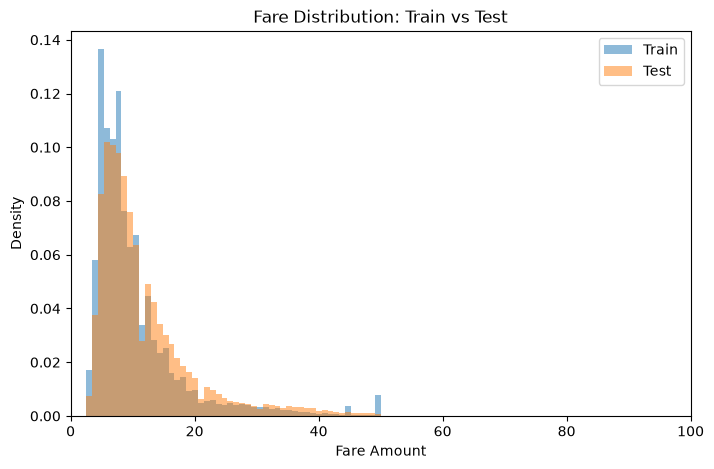

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(y_train, bins=50, alpha=0.5, label='Train', density=True)
plt.hist(y_test, bins=50, alpha=0.5, label='Test', density=True)
plt.xlabel('Fare Amount')
plt.ylabel('Density')
plt.legend()
plt.title('Fare Distribution: Train vs Test')
plt.xlim(0, 100)  # zoom past the long tail, same as before
plt.show()

## Step 3 : Pipeline -> (Encoding + scaling + Feature Engineering)

In [23]:
print(X_train_selected['Car Condition'].unique())
print(X_train_selected['Weather'].unique())
print(X_train_selected['Traffic Condition'].unique())

<StringArray>
['Very Good', 'Excellent', 'Bad', 'Good']
Length: 4, dtype: str
<StringArray>
['cloudy', 'sunny', 'windy', 'stormy', 'rainy']
Length: 5, dtype: str
<StringArray>
['Dense Traffic', 'Flow Traffic', 'Congested Traffic']
Length: 3, dtype: str


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# Define column groups
ordinal_col = ['Car Condition']
ordinal_order = [['Bad', 'Good', 'Very Good', 'Excellent']]
onehot_cols = ['Weather', 'Traffic Condition']
numeric_cols = ['passenger_count', 'weekday', 'month', 'year',
                 'jfk_dist', 'ewr_dist', 'lga_dist', 'nyc_dist',
                 'distance']  

# Numeric branch: scale only 
numeric_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical branches
ordinal_pipeline = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=ordinal_order))
])

onehot_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combine all branches 
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_cols),
    ('ord', ordinal_pipeline, ordinal_col),
    ('onehot', onehot_pipeline, onehot_cols)
], remainder='passthrough') 



In [25]:
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# One single call does imputation , encoding, scaling, AND fits the model
full_pipeline.fit(X_train_selected, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Car Condition','Weather','Traffic Condition',...,'distance','hour_sin', 'hour_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Thi

## Step 4 : HyperParameter Tuning + Cross validation

In [26]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline

# 1. DOWN-SAMPLE CHRONOLOGICALLY (Fast Tuning Alternative)
# We take every 10th row. This reduces dataset size by 90% while keeping chronological order intact!
X_train_sample = X_train_selected.iloc[::10]
y_train_sample = y_train.iloc[::10]

print(f"Original training size: {X_train_selected.shape[0]:,}")
print(f"Tuning sample size:     {X_train_sample.shape[0]:,} (Chronological order preserved)")

# 2. Set up TimeSeriesSplit for temporal cross-validation
# This ensures each split respects the timeline of your taxi rides
tscv = TimeSeriesSplit(n_splits=5)

# 3. Create the training pipeline with Gradient Boosting
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

# 4. Define the search space specific to Gradient Boosting
gb_param_distributions = {
    'model__n_estimators': [50, 100, 150, 200],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 4, 5, 6],
    'model__min_samples_split': [2, 5, 10],
    'model__subsample': [0.8, 0.9, 1.0]  
}

# 5. Set up RandomizedSearchCV with TimeSeriesSplit
random_search_gb = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_param_distributions,
    n_iter=10,
    cv=tscv,               # Applied TimeSeriesSplit
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

print("\nStarting fast Gradient Boosting tuning with TimeSeriesSplit...")
random_search_gb.fit(X_train_sample, y_train_sample)
print("Tuning complete!")
print("Best Gradient Boosting Parameters:\n", random_search_gb.best_params_)

Original training size: 381,190
Tuning sample size:     38,119 (Chronological order preserved)

Starting fast Gradient Boosting tuning with TimeSeriesSplit...
Tuning complete!
Best Gradient Boosting Parameters:
 {'model__subsample': 0.9, 'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__max_depth': 4, 'model__learning_rate': 0.1}


## Step 5 : Evaluation of model accuracy 

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
import numpy as np

# 1. Re-fit the best model on 100% of the training data (all 381,190 rows)
print("Rebuilding and training the optimal Gradient Boosting model on the FULL training set...")

# Extract the best parameters and strip the 'model__' prefix
best_params = {k.replace('model__', ''): v for k, v in random_search_gb.best_params_.items()}

# Build a fresh pipeline using the optimal parameters
final_gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(**best_params, random_state=42))
])

# Fit on 100% of the data
final_gb_pipeline.fit(X_train_selected, y_train)
print("Training on full dataset complete!\n")


# 2. Helper function to compute evaluation metrics
def evaluate_pipeline(model_pipeline, X, y, name="Model"):
    predictions = model_pipeline.predict(X)
    mae = mean_absolute_error(y, predictions)
    rmse = np.sqrt(mean_squared_error(y, predictions))
    r2 = r2_score(y, predictions)
    
    print(f"=== {name} Performance on Test Set ===")
    print(f"MAE  (Mean Absolute Error):    {mae:.4f}")
    print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
    print(f"R²   (Coefficient of Det.):     {r2:.4f}\n")
    return {"MAE": mae, "RMSE": rmse, "R2": r2}


# 3. Evaluate your baseline model (from full_pipeline)
evaluate_pipeline(full_pipeline, X_test_selected, y_test, name="Baseline Linear Regression")

# 4. Evaluate your fully trained, tuned Gradient Boosting model
evaluate_pipeline(final_gb_pipeline, X_test_selected, y_test, name="Tuned Gradient Boosting (Full Train)")

Rebuilding and training the optimal Gradient Boosting model on the FULL training set...
Training on full dataset complete!

=== Baseline Linear Regression Performance on Test Set ===
MAE  (Mean Absolute Error):    2.3762
RMSE (Root Mean Squared Error): 3.6162
R²   (Coefficient of Det.):     0.7901

=== Tuned Gradient Boosting (Full Train) Performance on Test Set ===
MAE  (Mean Absolute Error):    1.8483
RMSE (Root Mean Squared Error): 2.9209
R²   (Coefficient of Det.):     0.8631



{'MAE': 1.8482996771837137,
 'RMSE': np.float64(2.9208676059275276),
 'R2': 0.8630719754119986}

In [28]:
import joblib

# file name
model_filename = "final_taxi_fare_gb_pipeline.joblib"

#Save the fitted pipeline
# This saves the preprocessor, scaling rules, and trained Gradient Boosting model altogether!
joblib.dump(final_gb_pipeline, filename=model_filename, compress=3)

print(f"The final fitted pipeline has been saved to: '{model_filename}'")

The final fitted pipeline has been saved to: 'final_taxi_fare_gb_pipeline.joblib'


In [29]:
# Load the saved pipeline
loaded_pipeline = joblib.load("final_taxi_fare_gb_pipeline.joblib")

# Instantly predict on your test set (no retraining or manual scaling needed!)
sample_predictions = loaded_pipeline.predict(X_test_selected.head(5))
print("Sample Predictions:", sample_predictions)

Sample Predictions: [ 9.30148979 10.79635037 14.72382907  8.16744147 10.70822967]
